# Using Ragas to Evaluate a RAG Application built with LangChain and LangGraph

In the following notebook, we'll be looking at how [Ragas](https://github.com/explodinggradients/ragas) can be helpful in a number of ways when looking to evaluate your RAG applications!

While this example is rooted in LangChain/LangGraph - Ragas is framework agnostic (you don't even need to be using a framework!).

- 🤝 Breakout Room #1
  1. Task 1: Installing Required Libraries
  2. Task 2: Set Environment Variables
  3. Task 3: Synthetic Dataset Generation for Evaluation using Ragas
  4. Task 4: Evaluating our Pipeline with Ragas
  5. Task 6: Making Adjustments and Re-Evaluating

But first! Let's set some dependencies!

## Dependencies and API Keys:

We'll also need to provide our API keys.

First, OpenAI's for our LLM/embedding model combination!

In [1]:
import os
from getpass import getpass
os.environ["OPENAI_API_KEY"] = getpass("Please enter your OpenAI API key!")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - which should hopefull be familiar at this point since it's our Loan Data use-case!

Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [2]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [3]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

/home/xtallet/AIMakerSpace/AIE7/08_Evaluating_RAG_With_Ragas/.venv/lib/python3.13/site-packages/pysbd/segmenter.py:66: SyntaxWarning: invalid escape sequence '\s'
  for match in re.finditer('{0}\s*'.format(re.escape(sent)), self.original_text):
/home/xtallet/AIMakerSpace/AIE7/08_Evaluating_RAG_With_Ragas/.venv/lib/python3.13/site-packages/pysbd/lang/arabic.py:29: SyntaxWarning: invalid escape sequence '\.'
  txt = re.sub('(?<={0})\.'.format(am), '∯', txt)
/home/xtallet/AIMakerSpace/AIE7/08_Evaluating_RAG_With_Ragas/.venv/lib/python3.13/site-packages/pysbd/lang/persian.py:29: SyntaxWarning: invalid escape sequence '\.'
  txt = re.sub('(?<={0})\.'.format(am), '∯', txt)


In [4]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs[:20], testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/17 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/20 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node


Applying SummaryExtractor:   0%|          | 0/31 [00:00<?, ?it/s]

Property 'summary' already exists in node '41c0d9'. Skipping!
Property 'summary' already exists in node '33f428'. Skipping!
Property 'summary' already exists in node 'dfbb5b'. Skipping!
Property 'summary' already exists in node '29e409'. Skipping!
Property 'summary' already exists in node '6f6c5b'. Skipping!
Property 'summary' already exists in node 'd0cf13'. Skipping!
Property 'summary' already exists in node 'e33cbe'. Skipping!
Property 'summary' already exists in node '655408'. Skipping!
Property 'summary' already exists in node '2abb68'. Skipping!
Property 'summary' already exists in node '6ddf52'. Skipping!
Property 'summary' already exists in node 'fa2ff4'. Skipping!
Property 'summary' already exists in node '288471'. Skipping!
Property 'summary' already exists in node 'ab852c'. Skipping!
Property 'summary' already exists in node 'a71f75'. Skipping!


...

Property 'summary_embedding' already exists in node 'a71f75'. Skipping!
Property 'summary_embedding' already exists in node 'fa2ff4'. Skipping!
Property 'summary_embedding' already exists in node '655408'. Skipping!
Property 'summary_embedding' already exists in node 'd0cf13'. Skipping!
Property 'summary_embedding' already exists in node 'ab852c'. Skipping!
Property 'summary_embedding' already exists in node '33f428'. Skipping!
Property 'summary_embedding' already exists in node '2abb68'. Skipping!
Property 'summary_embedding' already exists in node '41c0d9'. Skipping!
Property 'summary_embedding' already exists in node 'dfbb5b'. Skipping!
Property 'summary_embedding' already exists in node '288471'. Skipping!
Property 'summary_embedding' already exists in node '6ddf52'. Skipping!
Property 'summary_embedding' already exists in node '6f6c5b'. Skipping!
Property 'summary_embedding' already exists in node '29e409'. Skipping!
Property 'summary_embedding' already exists in node 'e33cbe'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [5]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,What is a Scheduled Academic Year (SAY) in the...,"[non-term (includes clock-hour calendars), or ...",In a program using a Scheduled Academic Year (...,single_hop_specifc_query_synthesizer
1,"i need know what Volume 8, Chapter 3 say about...",[Inclusion of Clinical Work in a Standard Term...,"See Volume 8, Chapter 3 for additional guidanc...",single_hop_specifc_query_synthesizer
2,"What Non-Term Characteristics is for program, ...",[Non-Term Characteristics A program that measu...,A program has Non-Term Characteristics if it m...,single_hop_specifc_query_synthesizer
3,Wher can I find the rules about Direct Loan an...,[both the credit or clock hours and the weeks ...,For information on Direct Loan annual loan lim...,single_hop_specifc_query_synthesizer
4,How do the disbursement requirements and timin...,[<1-hop>\n\nboth the credit or clock hours and...,In clock-hour or non-term credit-hour programs...,multi_hop_abstract_query_synthesizer
5,"According to federal regulations, under what c...",[<1-hop>\n\nInclusion of Clinical Work in a St...,A practicum or clinical experience required fo...,multi_hop_abstract_query_synthesizer
6,If a medical or education program requires all...,[<1-hop>\n\nInclusion of Clinical Work in a St...,When a medical or education program requires a...,multi_hop_abstract_query_synthesizer
7,How do the disbursement requirements and timin...,[<1-hop>\n\nboth the credit or clock hours and...,In clock-hour or non-term credit-hour programs...,multi_hop_abstract_query_synthesizer
8,if a student in a clock-hour or non-term credi...,[<1-hop>\n\nboth the credit or clock hours and...,If a student in a clock-hour or non-term credi...,multi_hop_specific_query_synthesizer
9,How do the disbursement requirements for Direc...,[<1-hop>\n\nDisbursement Timing in Subscriptio...,"In subscription-based programs, for the first ...",multi_hop_specific_query_synthesizer


## LangChain RAG

Now we'll construct our LangChain RAG, which we will be evaluating using the above created test data!

### R - Retrieval

Let's start with building our retrieval pipeline, which will involve loading the same data we used to create our synthetic test set above.

> NOTE: We need to use the same data - as our test set is specifically designed for this data.

In [6]:
path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

Now that we have our data loaded, let's split it into chunks!

In [7]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

1102

#### ❓ Question: 

What is the purpose of the `chunk_overlap` parameter in the `RecursiveCharacterTextSplitter`?

##### ✅ Answer:

The `chunk_overlap` parameter defines how many characters are repeated / overlapped between one chunk and the next when splitting the next.<br>

This helps ensure that important information at the end of one chunk is not lost and is also present at the beginning of the next chunk, improving coherence and context between chunks.

Next up, we'll need to provide an embedding model that we can use to construct our vector store.

In [8]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can build our in memory QDrant vector store.

In [9]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="loan_data",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="loan_data",
    embedding=embeddings,
)

We can now add our documents to our vector store.

In [10]:
_ = vector_store.add_documents(documents=split_documents)

Let's define our retriever.

In [11]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

Now we can produce a node for retrieval!

In [12]:
def retrieve(state):
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

### Augmented

Let's create a simple RAG prompt!

In [13]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

### Generation

We'll also need an LLM to generate responses - we'll use `gpt-4o-nano` to avoid using the same model as our judge model.

In [14]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

Then we can create a `generate` node!

In [15]:
def generate(state):
  docs_content = "\n\n".join(doc.page_content for doc in state["context"])
  messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
  response = llm.invoke(messages)
  return {"response" : response.content}

### Building RAG Graph with LangGraph

Let's create some state for our LangGraph RAG graph!

In [16]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

Now we can build our simple graph!

> NOTE: We're using `add_sequence` since we will always move from retrieval to generation. This is essentially building a chain in LangGraph.

In [17]:
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

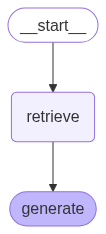

In [19]:
# 🏗️ XTALLET - Print Graph Diagram

graph

Let's do a test to make sure it's doing what we'd expect.

In [20]:
response = graph.invoke({"question" : "What are the different kinds of loans?"})

In [21]:
response["response"]

'Based on the provided context, the different kinds of loans mentioned are:\n\n1. **Direct Loan**  \n   - This includes various types of federal student loans, such as the Direct Unsubsidized Loan and potentially others implied by the context.\n\n2. **Direct Unsubsidized Loan**  \n   - A specific type of Direct Loan where interest may accrue during in-school periods unless paid by the borrower.\n\nThe context primarily discusses the administration and transfer of these loans rather than detailing additional loan types outside the Direct Loan program.'

## Evaluating the App with Ragas

Now we can finally do our evaluation!

We'll start by running the queries we generated usign SDG above through our application to get context and responses.

In [22]:
for test_row in dataset:
  response = graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

In [23]:
dataset.samples[0].eval_sample.response

'A Scheduled Academic Year (SAY) in the context of standard term academic calendars is a traditional academic year calendar that typically begins and ends at the same time each year. It usually includes two or more standard terms such as semesters, trimesters, or quarters that span the fall through spring. An SAY must meet the Title IV requirements for an academic year, including the minimum credit hours and weeks of instructional time. It can also include comparable academic calendars with SE9W nonstandard terms if all terms are SE9W and meet regulatory minimums.'

Then we can convert that table into a `EvaluationDataset` which will make the process of evaluation smoother.

In [24]:
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

We'll need to select a judge model - in this case we're using the same model that was used to generate our Synthetic Data.

In [25]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))

Next up - we simply evaluate on our desired metrics!

In [26]:
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas import evaluate, RunConfig

custom_run_config = RunConfig(timeout=360)

result = evaluate(
    dataset=evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
result

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

{'context_recall': 0.7988, 'faithfulness': 0.9380, 'factual_correctness': 0.5442, 'answer_relevancy': 0.8704, 'context_entity_recall': 0.3587, 'noise_sensitivity_relevant': 0.2905}

## Making Adjustments and Re-Evaluating

Now that we've got our baseline - let's make a change and see how the model improves or doesn't improve!

> NOTE: This will be using Cohere's Rerank model - please be sure to [sign-up for an API key!](https://docs.cohere.com/reference/about)

In [27]:
os.environ["COHERE_API_KEY"] = getpass("Please enter your Cohere API key!")


We'll first set our retriever to return more documents, which will allow us to take advantage of the reranking.

In [28]:
adjusted_example_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

Reranking, or contextual compression, is a technique that uses a reranker to compress the retrieved documents into a smaller set of documents.

This is essentially a slower, more accurate form of semantic similarity that we use on a smaller subset of our documents.

In [29]:
# 🏗️ XTALLET Notes - This function retrieves the 5 most relevant documents for a given question, 
# first using a base retriever and then applying a reranker (Cohere) to reorder and filter 
# the results, returning only the most relevant ones.

from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

def retrieve_adjusted(state):
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=adjusted_example_retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

We can simply rebuild our graph with the new retriever!

In [30]:
class AdjustedState(TypedDict):
  question: str
  context: List[Document]
  response: str

adjusted_graph_builder = StateGraph(AdjustedState).add_sequence([retrieve_adjusted, generate])
adjusted_graph_builder.add_edge(START, "retrieve_adjusted")
adjusted_graph = adjusted_graph_builder.compile()

In [31]:
response = adjusted_graph.invoke({"question" : "What are the different kinds of loans?"})
response["response"]

'The provided context mentions the following kinds of loans:\n\n1. Federal PLUS Loans\n2. Direct Subsidized Loans\n3. Direct Unsubsidized Loans\n4. Student Direct PLUS Loans (a specific type of PLUS Loan)'

In [33]:
import time
import copy

rerank_dataset = copy.deepcopy(dataset)

for test_row in rerank_dataset:
  response = adjusted_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
  time.sleep(5) # To try to avoid rate limiting.

In [34]:
rerank_dataset.samples[0].eval_sample.response

"A Scheduled Academic Year (SAY) is a traditional academic year calendar that is published in a school's catalog or other materials. It is a fixed period of time that generally begins and ends at the same time each year, such as starting on the first day of the fall semester and ending on the last day of the spring semester. An SAY corresponds to a traditional academic year calendar and can be used by programs with standard terms and a traditional academic calendar or by programs with SE9W nonstandard terms and a comparable calendar."

In [35]:
rerank_evaluation_dataset = EvaluationDataset.from_pandas(rerank_dataset.to_pandas())

In [36]:
result = evaluate(
    dataset=rerank_evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
result

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

{'context_recall': 0.8567, 'faithfulness': 0.9361, 'factual_correctness': 0.6033, 'answer_relevancy': 0.8560, 'context_entity_recall': 0.4271, 'noise_sensitivity_relevant': 0.2354}

#### ❓ Question: 

Which system performed better, on what metrics, and why?

##### ✅ Answer:

<b>Results Without Cohere: </b>
{'context_recall': 0.7988, 'faithfulness': 0.9380, 'factual_correctness': 0.5442, 'answer_relevancy': 0.8704, 'context_entity_recall': 0.3587, 'noise_sensitivity_relevant': 0.2905}


<b> Results With Cohere: </b> 
{'context_recall': 0.8567, 'faithfulness': 0.9361, 'factual_correctness': 0.6033, 'answer_relevancy': 0.8560, 'context_entity_recall': 0.4271, 'noise_sensitivity_relevant': 0.2354}

I am going to add a Step by Step comparing each one :<br>

- <b>Context Recall:</b> <br><br>
  Without Cohere: 0.7988<br>
  With Cohere: 0.8567

  Explanation:<br>
  Using Cohere as a reranker significantly improved context recall. This means the system was better at retrieving the relevant pieces of information needed to answer the questions. The reranker helps prioritize the most pertinent document chunks, leading to more accurate retrieval.
  <br><br>

- <b>Faithfulness:</b> <br><br>
  Without Cohere: 0.9380<br>
  With Cohere: 0.9361

  Explanation:<br>
  Faithfulness remained very high in both cases, with only a minimal decrease when using Cohere. This indicates that the answers generated were consistently supported by the retrieved context, regardless of the reranking step.
  <br><br>

- <b>Factual Correctness:</b> <br><br>
  Without Cohere: 0.5442<br>
  With Cohere: 0.6033

  Explanation:<br>
  Factual correctness improved with Cohere. By retrieving more relevant and accurate context, the system was able to generate answers that were more factually correct, reducing the likelihood of hallucinations or incorrect statements.
  <br><br>

- <b>Answer Relevancy:</b> <br><br>
  Without Cohere: 0.8704<br>
  With Cohere: 0.8560

  Explanation:<br>
  Answer relevancy was slightly higher without Cohere, but the difference is very small. This suggests that the reranking step did not negatively impact the system’s ability to generate relevant answers to the questions.
  <br><br>

- <b>Context Entity Recall:</b> <br><br>
  Without Cohere: 0.3587<br>
  With Cohere: 0.4271

  Explanation:<br>
  There was a notable improvement in context entity recall with Cohere. The system was better at retrieving context that included the key entities needed for answering the questions, thanks to the improved selection of relevant document chunks.
  <br><br>

- <b>Noise Sensitivity Relevant:</b> <br><br>
  Without Cohere: 0.2905<br>
  With Cohere: 0.2354

  Explanation:<br>
  Noise sensitivity was lower (better) with Cohere. This means the system was less likely to be distracted by irrelevant information, leading to more focused and accurate answers.


<b>General Summary:</b> <br>
Overall, using Cohere as a reranker led to improvements in most key metrics, especially in context recall, factual correctness, and context entity recall. The system became better at retrieving and using the most relevant information, resulting in more accurate and reliable answers. The small decrease in answer relevancy and faithfulness is negligible compared to the overall gains. In summary, the Cohere-enhanced system demonstrates a clear advantage in producing high-quality, contextually accurate responses.